In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.0001, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def _sigmoid(self, z):
        """The sigmoid activation function: 1 / (1 + e^-z)"""
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        """
        Training step using Gradient Descent.
        """
        n_samples, n_features = X.shape

        # 1. Initialize parameters (weights and bias) to zeros
        self.weights = np.zeros(n_features)
        self.bias = 0

        # 2. Gradient Descent Loop
        for _ in range(self.n_iterations):
            # linear equation: z = w*x + b
            linear_model = np.dot(X, self.weights) + self.bias

            # Apply activation function
            y_predicted = self._sigmoid(linear_model)

            # Compute Gradients (derivative of the loss with respect to weights and bias)
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        """
        Returns class labels (0 or 1) based on probability threshold of 0.5
        """
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self._sigmoid(linear_model)
        # Convert probabilities to 0 or 1 class labels
        y_predicted_cls = [1 if i > 0.5 else 0 for i in y_predicted]
        return np.array(y_predicted_cls)

Text(0, 0.5, 'feature 2')

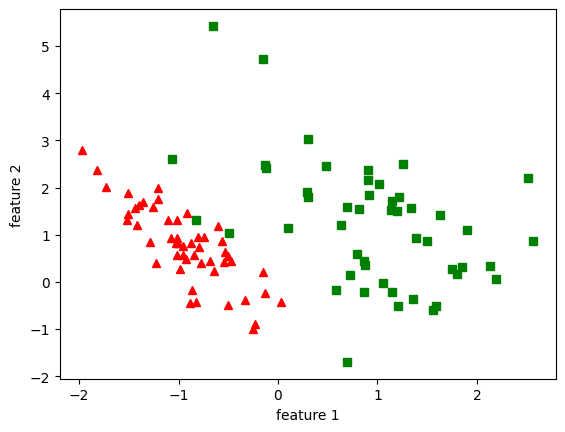

In [ ]:
X, y = make_classification(n_features=2, n_redundant=0, n_informative=2, random_state=2, n_clusters_per_class=1)
#PLot the dataset
fig = plt.figure()
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "r^")
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "gs")
plt.xlabel("feature 1")
plt.ylabel("feature 2")

In [ ]:
# Splitting the dataset into training and test set.

x_train, x_test, y_train, y_test= train_test_split(X, y, test_size= 0.20, random_state=0,shuffle=True)

In [ ]:
classifier= LogisticRegressionScratch()
classifier.fit(x_train, y_train)

In [ ]:
#Predicting the test set result
y_pred= classifier.predict(x_test)

In [ ]:
accuracy_score(y_test, y_pred)

1.0

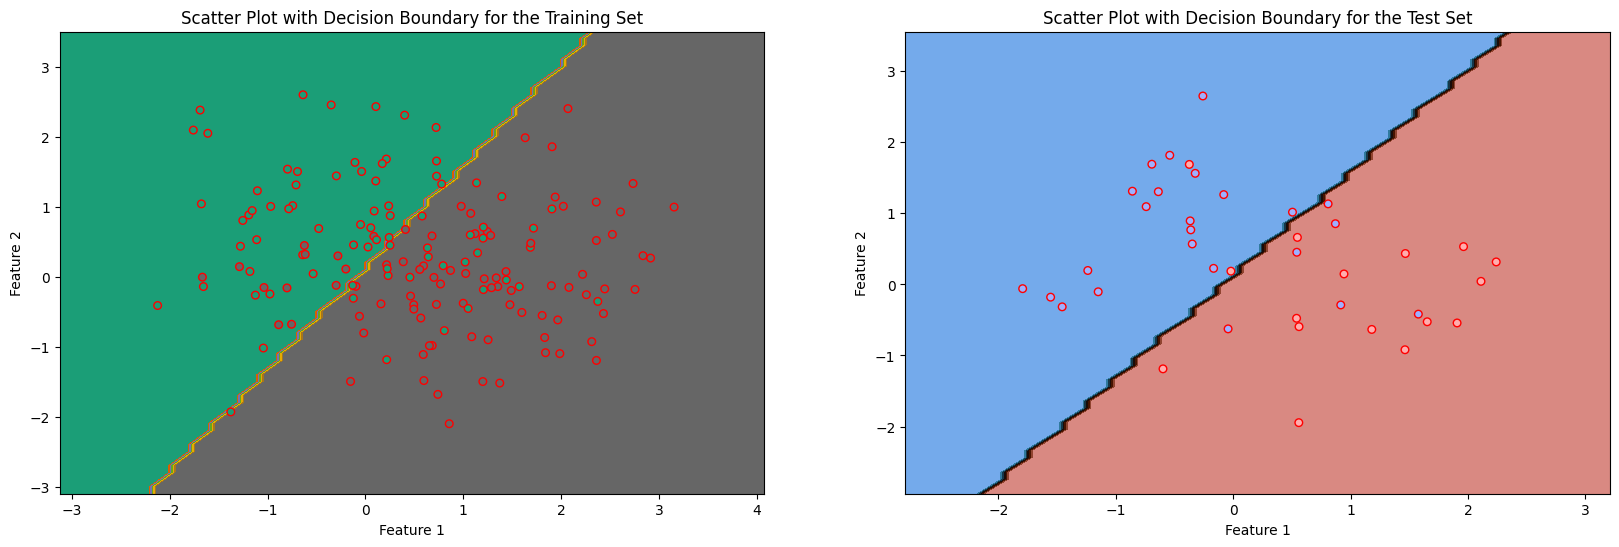

In [ ]:
# plotting the decision boundary in the scatter plot of Training and Test Set with labels indicated by colors
'''Finds the minimum and maximum values of Feature 1 (x_train[:, 0]) and Feature 2 (x_train[:, 1]).
The -1 and +1 provide a margin around the data points to ensure the decision boundary extends slightly beyond them.'''
x_min, x_max = x_train[:, 0].min() - 1, x_train[:, 0].max() + 1
y_min, y_max = x_train[:, 1].min() - 1, x_train[:, 1].max() + 1

'''np.meshgrid() creates a grid of points covering the feature space.
np.arange(x_min, x_max, 0.1) generates points from x_min to x_max with a step size of 0.1.
This results in a grid of points (xx_train, yy_train) over which predictions will be made.'''
xx_train, yy_train = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

'''np.c_[xx_train.ravel(), yy_train.ravel()] flattens the grid and combines xx_train and yy_train into a list of feature pairs.
classifier.predict(...) predicts the class for each point in the grid.'''
Z_train = classifier.predict(np.c_[xx_train.ravel(), yy_train.ravel()])
Z_train = Z_train.reshape(xx_train.shape)

#####################################Repeat for test set #############################################################
x_min, x_max = x_test[:, 0].min() - 1, x_test[:, 0].max() + 1
y_min, y_max = x_test[:, 1].min() - 1, x_test[:, 1].max() + 1

xx_test, yy_test = np.meshgrid(np.arange(x_min, x_max, 0.1),
                               np.arange(y_min, y_max, 0.1))

Z_test = classifier.predict(np.c_[xx_test.ravel(), yy_test.ravel()])
Z_test = Z_test.reshape(xx_test.shape)



plt.figure(figsize = (20, 6))
plt.subplot(1, 2, 1) #training set.
plt.contourf(xx_train, yy_train, Z_train, cmap = plt.cm.Dark2) #Plots the decision boundary.
plt.scatter(x_train[:, 0], x_train[:, 1], c = y_train, s = 30, edgecolor = 'red', cmap = plt.cm.Dark2) #Plots the training points.
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter Plot with Decision Boundary for the Training Set')

plt.subplot(1, 2, 2)
plt.contourf(xx_test, yy_test, Z_test, cmap = plt.cm.berlin)
plt.scatter(x_test[:, 0], x_test[:, 1], c = y_test, s = 30, edgecolor = 'red', cmap = plt.cm.berlin)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter Plot with Decision Boundary for the Test Set')
plt.show()

In [ ]:
# importing libraries
import matplotlib.pyplot as plt
import pandas as pd
import io
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score
import numpy as np

# Create dataset (adding noise) -->non-linear dataset
# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html
X, y = make_moons(n_samples=200, noise=0.75)

Text(0, 0.5, 'feature 2')

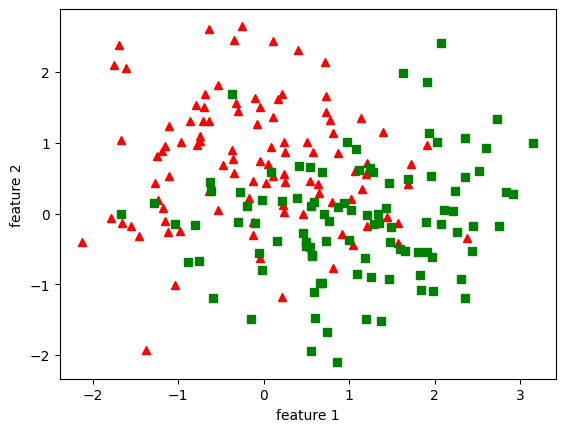

In [ ]:
#PLot the dataset
fig = plt.figure()
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "r^")
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "gs")
plt.xlabel("feature 1")
plt.ylabel("feature 2")

In [ ]:
# Splitting the dataset into training and test set.

x_train, x_test, y_train, y_test= train_test_split(X, y, test_size= 0.20, random_state=0, shuffle=True)

In [ ]:
#Fitting Logistic Regression to the training set
classifier= LogisticRegressionScratch()
classifier.fit(x_train, y_train)

In [ ]:
#Predicting the test set result
y_pred= classifier.predict(x_test)

In [ ]:
accuracy_score(y_test, y_pred)

0.8

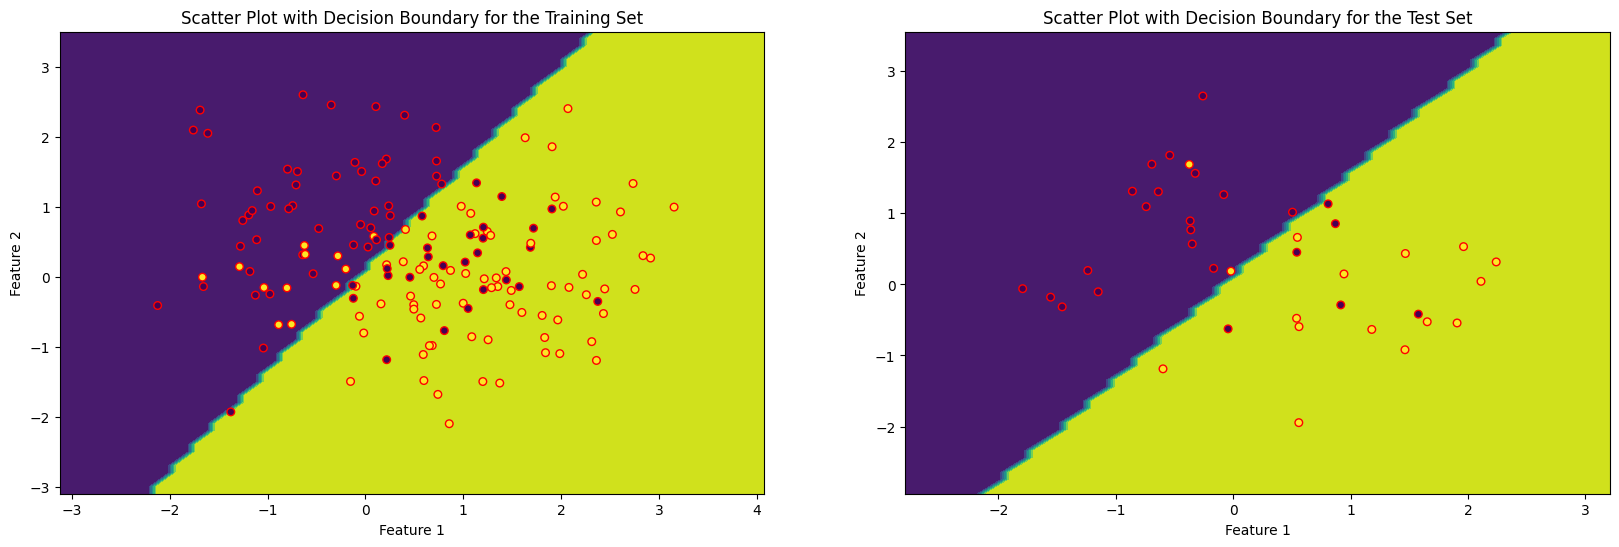

In [ ]:
# plotting the decision boundary in the scatter plot of Training and Test Set with labels indicated by colors
x_min, x_max = x_train[:, 0].min() - 1, x_train[:, 0].max() + 1
y_min, y_max = x_train[:, 1].min() - 1, x_train[:, 1].max() + 1

xx_train, yy_train = np.meshgrid(np.arange(x_min, x_max, 0.1),
                                 np.arange(y_min, y_max, 0.1))

Z_train = classifier.predict(np.c_[xx_train.ravel(), yy_train.ravel()])
Z_train = Z_train.reshape(xx_train.shape)


x_min, x_max = x_test[:, 0].min() - 1, x_test[:, 0].max() + 1
y_min, y_max = x_test[:, 1].min() - 1, x_test[:, 1].max() + 1

xx_test, yy_test = np.meshgrid(np.arange(x_min, x_max, 0.1),
                               np.arange(y_min, y_max, 0.1))

Z_test = classifier.predict(np.c_[xx_test.ravel(), yy_test.ravel()])
Z_test = Z_test.reshape(xx_test.shape)



plt.figure(figsize = (20, 6))
plt.subplot(1, 2, 1)
plt.contourf(xx_train, yy_train, Z_train)
plt.scatter(x_train[:, 0], x_train[:, 1], c = y_train, s = 30, edgecolor = 'red')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter Plot with Decision Boundary for the Training Set')
plt.subplot(1, 2, 2)
plt.contourf(xx_test, yy_test, Z_test)
plt.scatter(x_test[:, 0], x_test[:, 1], c = y_test, s = 30, edgecolor = 'red')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter Plot with Decision Boundary for the Test Set')
plt.show()